In [55]:
import torch 
from torch import nn
import torch_geometric
from torch_geometric.datasets import QM9
from torch_geometric.loader import DataLoader
import matplotlib.pyplot as plt
import networkx as nx
from torch_geometric.utils import to_networkx

In [56]:
dataset = QM9(root="data/QM9")
data = dataset[0]
mean = dataset.data.y[:, 0].mean().item()
std = dataset.data.y[:, 0].std().item()
print(dataset)
device = "cpu"
mean, std

QM9(130831)


/var/folders/37/lf0ksvzx3_11_c3r_ltd0dpw0000gn/T/ipykernel_59283/2827363895.py:3: UserWarning: It is not recommended to directly access the internal storage format `data` of an 'InMemoryDataset'. The data of the dataset is already cached, so any modifications to `data` will not be reflected when accessing its elements. Clearing the cache now by removing all elements in `dataset._data_list`. If you are absolutely certain what you are doing, access the internal storage via `InMemoryDataset._data` instead to suppress this warning. Alternatively, you can access stacked individual attributes of every graph via `dataset.{attr_name}`.
  mean = dataset.data.y[:, 0].mean().item()
/var/folders/37/lf0ksvzx3_11_c3r_ltd0dpw0000gn/T/ipykernel_59283/2827363895.py:4: UserWarning: It is not recommended to directly access the internal storage format `data` of an 'InMemoryDataset'. If you are absolutely certain what you are doing, access the internal storage via `InMemoryDataset._data` instead to suppres

(2.6729531288146973, 1.5034793615341187)

In [57]:
dataset.num_classes, dataset.num_node_features, dataset.num_edge_features , len(dataset)

(19, 11, 4, 130831)

In [58]:
train_dataset = dataset[:int(0.8 * len(dataset))]
test_dataset = dataset[int(0.8 * len(dataset)):]

In [59]:
train_dataset, test_dataset

(QM9(104664), QM9(26167))

In [60]:
# from torch.utils.data._utils.collate import default_collate
# def collate_to_device(batch):
#     X, y = default_collate(batch)
#     return X, y

In [61]:
BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,  shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE,  shuffle=False)

In [62]:
import torch
from torch import nn
import torch.nn.functional as F
from torch_geometric.nn import MessagePassing

class CustomMPNNLayer(MessagePassing):
    def __init__(self, node_channels, edge_channels, out_channels):
        super().__init__(aggr='add') 
        
        self.msg_mlp = nn.Sequential(
            nn.Linear(2 * node_channels + edge_channels, out_channels),
            nn.BatchNorm1d(out_channels),
            nn.ReLU(),
            nn.Linear(out_channels, out_channels)
        )
        
        self.update_mlp = nn.Sequential(
            nn.Linear(node_channels + out_channels, out_channels),
            nn.BatchNorm1d(out_channels),
            nn.ReLU(),
            nn.Linear(out_channels, out_channels)
        )

    def forward(self, x, edge_index, edge_attr):
        return self.propagate(edge_index, x=x, edge_attr=edge_attr)

    def message(self, x_i, x_j, edge_attr):
        tmp = torch.cat([x_i, x_j, edge_attr], dim=1)
        return self.msg_mlp(tmp)

    def update(self, aggr_out, x):
        tmp = torch.cat([x, aggr_out], dim=1)
        return self.update_mlp(tmp)

In [63]:
dataset.num_node_features, dataset.num_edge_features

(11, 4)

In [64]:
import torch.nn.functional as F
from torch_geometric.nn import global_add_pool

class CustomQM9Model(nn.Module):
    def __init__(self, node_in_dim=11, edge_in_dim=4, hidden_dim=64):
        super().__init__()
        self.node_proj = nn.Linear(node_in_dim, hidden_dim)
        self.conv1 = CustomMPNNLayer(node_channels=hidden_dim,
                                     edge_channels=edge_in_dim,
                                     out_channels=hidden_dim)

        self.conv2 = CustomMPNNLayer(node_channels=hidden_dim,
                                     edge_channels=edge_in_dim,
                                     out_channels=hidden_dim)

        self.head = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, hidden_dim // 4),
            nn.ReLU(),
            nn.Linear(hidden_dim // 4, 1)
        )

    def forward(self, data):
        x, edge_index, edge_attr, batch = data.x, data.edge_index, data.edge_attr, data.batch
        x = self.node_proj(x)
        x = F.relu(x)
        x = self.conv1(x, edge_index, edge_attr)
        x = F.relu(x)
        x = self.conv2(x, edge_index, edge_attr)
        x = F.relu(x)
        graph_emb = global_add_pool(x, batch)

        return self.head(graph_emb).squeeze()

torch.manual_seed(42)
model_mpnn = CustomQM9Model().to(device)

In [65]:
model_mpnn.state_dict()

OrderedDict([('node_proj.weight',
              tensor([[ 0.2305,  0.2503, -0.0706,  0.2770, -0.0661,  0.0608, -0.1468,  0.1771,
                        0.2658, -0.2212,  0.2621],
                      [ 0.0564,  0.2228,  0.0408,  0.1454, -0.0426,  0.2324,  0.0446, -0.1408,
                        0.0769, -0.1389, -0.0354],
                      [-0.1225,  0.2000, -0.2380, -0.1390, -0.0851, -0.1813,  0.0285, -0.2978,
                        0.2723, -0.2561,  0.2328],
                      [ 0.0502, -0.0979,  0.1863,  0.0470,  0.2436,  0.0330, -0.0951,  0.0810,
                       -0.0818,  0.1269,  0.2692],
                      [ 0.1743, -0.1318,  0.1741,  0.0539,  0.1531, -0.1838, -0.2985, -0.1165,
                       -0.2313,  0.2474,  0.0868],
                      [ 0.1249,  0.0954, -0.0052,  0.2360, -0.2142,  0.0190, -0.2058,  0.0930,
                       -0.1038,  0.0924, -0.0628],
                      [ 0.2501, -0.1787, -0.1798, -0.1798,  0.2712,  0.1005,  0.2901, -0.2

In [66]:
unique_params = sum(dict((p.data_ptr(), p.numel()) for p in model_mpnn.parameters()).values())
unique_params

54081

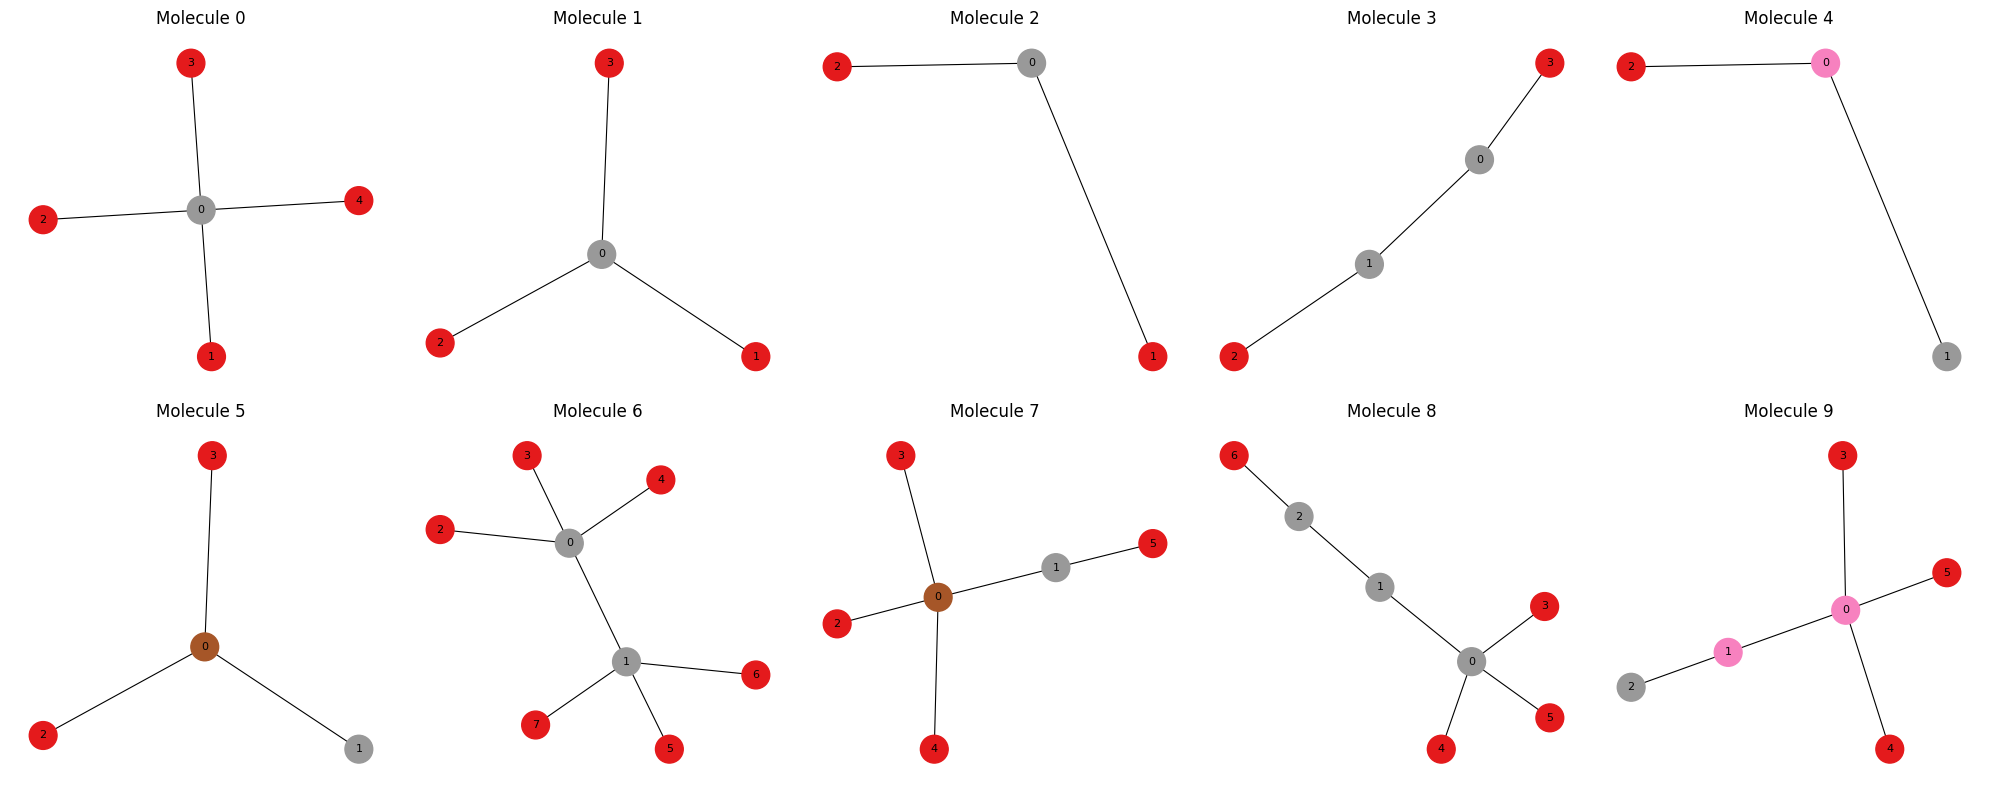

In [67]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten() 

for i in range(10):
    data = dataset[i]
    
    g = to_networkx(data, to_undirected=True)
    pos = nx.spring_layout(g, seed=0)
    
    node_color = data.z.detach().cpu().numpy()
    
    ax = axes[i]
    nx.draw_networkx(
        g,
        pos=pos,
        ax=ax,                 
        node_size=400,
        width=0.8,
        edge_color='black',
        with_labels=True,
        node_color=node_color,
        cmap='Set1',
        font_size=8
    )
    
    ax.set_title(f"Molecule {i}")
    ax.axis('off')

plt.tight_layout()
plt.show()

In [68]:
data

Data(x=[6, 11], edge_index=[2, 10], edge_attr=[10, 4], y=[1, 19], pos=[6, 3], idx=[1], name='gdb_10', z=[6])

In [69]:
loss  = nn.MSELoss()
optimizer = torch.optim.Adam(model_mpnn.parameters(), lr=0.001)

In [70]:
def accuracy(pred_y, y, tol=0.5):
    return (torch.abs(pred_y - y) < tol).float().mean().item()

In [71]:
epochs = 20
train_losses = []
test_losses = []
accuracies = []
outputs = []

criterion = nn.MSELoss()

for epoch in range(epochs):
    model_mpnn.train()
    total_loss = 0.0
    for data in train_loader:
        data = data.to(device)
        optimizer.zero_grad()
        out = model_mpnn(data)
        target_normalized = (data.y[:, 0] - mean) / std
        batch_loss = criterion(out.view(-1), target_normalized)
        batch_loss.backward()
        optimizer.step()
        total_loss += batch_loss.item() * data.num_graphs

    avg_train_loss = total_loss / len(train_loader.dataset)
    train_losses.append(avg_train_loss)

    model_mpnn.eval()
    total_loss = 0.0
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for data in test_loader:
            data = data.to(device)
            out = model_mpnn(data)
            target_normalized = (data.y[:, 0] - mean) / std
            batch_loss = criterion(out.view(-1), target_normalized)
            total_loss += batch_loss.item() * data.num_graphs
            all_preds.append(out.view(-1).cpu())
            all_labels.append(target_normalized.cpu())

    avg_test_loss = total_loss / len(test_loader.dataset)
    test_losses.append(avg_test_loss)

    all_preds = torch.cat(all_preds)
    all_labels = torch.cat(all_labels)
    acc = accuracy(all_preds, all_labels)
    accuracies.append(acc)

    print(f"Epoch {epoch+1}/{epochs}, Train Loss: {avg_train_loss:.4f}, Test Loss: {avg_test_loss:.4f}, Accuracy@tol: {acc:.4f}")

Epoch 1/20, Train Loss: 0.4180, Test Loss: 0.4188, Accuracy@tol: 0.6150
Epoch 2/20, Train Loss: 0.3327, Test Loss: 0.4245, Accuracy@tol: 0.6155
Epoch 3/20, Train Loss: 0.3113, Test Loss: 0.5437, Accuracy@tol: 0.5659
Epoch 4/20, Train Loss: 0.2919, Test Loss: 0.4732, Accuracy@tol: 0.5992
Epoch 5/20, Train Loss: 0.2805, Test Loss: 0.3907, Accuracy@tol: 0.6408
Epoch 6/20, Train Loss: 0.2726, Test Loss: 0.3488, Accuracy@tol: 0.6603
Epoch 7/20, Train Loss: 0.2655, Test Loss: 0.3455, Accuracy@tol: 0.6504
Epoch 8/20, Train Loss: 0.2582, Test Loss: 0.3190, Accuracy@tol: 0.6684
Epoch 9/20, Train Loss: 0.2530, Test Loss: 0.3223, Accuracy@tol: 0.6718
Epoch 10/20, Train Loss: 0.2500, Test Loss: 0.3494, Accuracy@tol: 0.6455
Epoch 11/20, Train Loss: 0.2454, Test Loss: 0.3176, Accuracy@tol: 0.6737
Epoch 12/20, Train Loss: 0.2404, Test Loss: 0.3073, Accuracy@tol: 0.6831
Epoch 13/20, Train Loss: 0.2368, Test Loss: 0.2986, Accuracy@tol: 0.6878
Epoch 14/20, Train Loss: 0.2349, Test Loss: 0.3059, Accuracy